In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("Data/Sample_Data/sample_data.csv")

In [6]:
data

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Packet Length Mean,Packet Length Std,Average Packet Size,Label
0,30447,1,1,52,113,52.000000,113.000000,5.419253e+03,65.687917,3.044700e+04,0.000000e+00,30447,30447,72.333333,35.218366,108.500000,Benign
1,102089,1,1,48,113,48.000000,113.000000,1.577055e+03,19.590749,1.020890e+05,0.000000e+00,102089,102089,69.666667,37.527767,104.500000,Benign
2,163472,1,1,38,54,38.000000,54.000000,5.627875e+02,12.234511,1.634720e+05,0.000000e+00,163472,163472,43.333333,9.237604,65.000000,Benign
3,117644950,16,14,899,4392,56.187500,313.714286,4.497431e+01,0.255005,4.056722e+06,1.500000e+07,58600000,3,170.677419,399.991199,176.366667,Benign
4,141647,3,5,352,11595,117.333333,2319.000000,8.434347e+04,56.478429,2.023529e+04,4.823406e+04,129162,4,1327.444444,3337.293930,1493.375000,Malicious
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,50,3,1,43,6,14.333333,6.000000,9.800000e+05,80000.000000,1.666667e+01,2.454248e+01,45,2,11.000000,11.180340,13.750000,Benign
249996,207,2,2,82,254,41.000000,127.000000,1.623188e+06,19323.671498,6.900000e+01,1.134504e+02,200,3,75.400000,47.104140,94.250000,Benign
249997,99535772,7,6,413,11595,59.000000,1932.500000,1.206400e+02,0.130606,8.294648e+06,2.870000e+07,99400000,1,857.714286,1458.944741,923.692308,Malicious
249998,17678865,11,6,369,11632,33.545455,1938.666667,6.788332e+02,0.961600,1.104929e+06,1.977174e+06,5665347,4,666.722222,1508.439856,705.941176,Malicious


In [ ]:
# plot settings
plt.style.use('default')
sns.set_theme()
pd.set_option('display.max_columns', None)

In [170]:
selected_features = [
    'Packet Length Mean',
    'Packet Length Std',
    'Average Packet Size',
    'Flow Duration',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Flow IAT Min',
    'Flow IAT Max',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean'
]

In [171]:
print(selected_features)

['Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min', 'Flow IAT Max', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean']


In [172]:
missing = [col for col in selected_features if col not in data.columns]
print("Missing columns:", missing)

Missing columns: []


In [100]:
data[selected_features].head()

,Packet Length Mean,Packet Length Std,Average Packet Size,Flow Duration,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Min,Flow IAT Max,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean
0,111.84,239.69,113.15,1266342,7595.10,67.12,15075.50,104051.40,0,948537,41,44,2664,6954,64.98,158.05
1,111.84,239.69,113.15,1319353,7289.94,64.43,15706.58,104861.87,1,955790,41,44,2664,6954,64.98,158.05
2,0.00,0.00,0.00,160,0.00,12500.00,160.00,0.00,160,160,1,1,0,0,0.00,0.00
3,111.45,241.64,112.80,1303488,7182.27,63.68,15896.20,106554.90,0,956551,41,42,2728,6634,66.54,157.95
4,0.00,0.00,0.00,77,0.00,38961.04,38.50,14.85,28,49,1,2,0,0,0.00,0.00


In [101]:
print("Shape of dataset:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data.dtypes)

print("\nMissing values in selected features:")
print(data[selected_features + ['Label']].isnull().sum())

Shape of dataset: (1981493, 17)

Column names:
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 'Label']

Data types:
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
Total Length of Bwd Packets      int64
Fwd Packet Length Mean         float64
Bwd Packet Length Mean         float64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Flow IAT Mean                  float64
Flow IAT Std                   float64
Flow IAT Max                     int64
Flow IAT Min                     int64
Packet Length Mean             float64
Packet Length Std              float64
Av

In [102]:
# 1. Shape check
print(data.shape)

# 2. Columns check
print(set(selected_features).issubset(set(data.columns)))

# 3. Missing values check
print(data[selected_features].isnull().sum().sum())

# 4. Label check
print(data['Label'].value_counts())

(1981493, 17)
True
0
Label
Benign       1646115
Malicious     335378
Name: count, dtype: int64


In [103]:
data[selected_features + ['Label']].head()

,Packet Length Mean,Packet Length Std,Average Packet Size,Flow Duration,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Min,Flow IAT Max,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Label
0,111.84,239.69,113.15,1266342,7595.10,67.12,15075.50,104051.40,0,948537,41,44,2664,6954,64.98,158.05,Benign
1,111.84,239.69,113.15,1319353,7289.94,64.43,15706.58,104861.87,1,955790,41,44,2664,6954,64.98,158.05,Benign
2,0.00,0.00,0.00,160,0.00,12500.00,160.00,0.00,160,160,1,1,0,0,0.00,0.00,Benign
3,111.45,241.64,112.80,1303488,7182.27,63.68,15896.20,106554.90,0,956551,41,42,2728,6634,66.54,157.95,Benign
4,0.00,0.00,0.00,77,0.00,38961.04,38.50,14.85,28,49,1,2,0,0,0.00,0.00,Benign


In [104]:
data[selected_features + ['Label']].head().to_string()

'   Packet Length Mean  Packet Length Std  Average Packet Size  Flow Duration  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Min  Flow IAT Max  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Mean  Bwd Packet Length Mean   Label\n0              111.84             239.69               113.15        1266342       7595.10           67.12       15075.50     104051.40             0        948537                 41                      44                         2664                         6954                   64.98                  158.05  Benign\n1              111.84             239.69               113.15        1319353       7289.94           64.43       15706.58     104861.87             1        955790                 41                      44                         2664                         6954                   64.98                  158.05  Benign\n2                0.00            

In [105]:
eda_summary = data[selected_features].describe().T
eda_summary

,count,mean,std,min,25%,50%,75%,max
Packet Length Mean,1981493.00,238.56,342.32,0.00,48.20,75.53,259.50,3337.14
Packet Length Std,1981493.00,417.68,720.51,0.00,17.03,52.58,506.15,4731.52
Average Packet Size,1981493.00,264.67,369.95,0.00,61.00,100.57,273.52,3893.33
Flow Duration,1981493.00,21100410.62,38520212.11,-13.00,30529.00,138782.00,10409818.00,119999998.00
Flow Bytes/s,1981493.00,302047.32,5459687.50,-261000000.00,121.23,2686.16,13313.28,2071000000.00
Flow Packets/s,1981493.00,4647.11,38736.67,-2000000.00,0.79,33.09,130.93,4000000.00
Flow IAT Mean,1981493.00,1833199.07,5183139.75,-13.00,9369.00,48322.00,1499655.50,120000000.00
Flow IAT Std,1981493.00,4170148.76,9340954.15,0.00,93.53,32605.84,3013829.31,84800261.57
Flow IAT Min,1981493.00,210367.19,3349241.97,-14.00,2.00,4.00,68.00,120000000.00
Flow IAT Max,1981493.00,13095755.15,28326227.56,-13.00,26456.00,96005.00,9693904.00,120000000.00


In [106]:
eda_summary['median'] = data[selected_features].median()
eda_summary['skewness'] = data[selected_features].skew()
eda_summary['kurtosis'] = data[selected_features].kurtosis()

eda_summary

,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
Packet Length Mean,1981493.00,238.56,342.32,0.00,48.20,75.53,259.50,3337.14,75.53,1.86,2.53
Packet Length Std,1981493.00,417.68,720.51,0.00,17.03,52.58,506.15,4731.52,52.58,2.29,5.20
Average Packet Size,1981493.00,264.67,369.95,0.00,61.00,100.57,273.52,3893.33,100.57,1.96,3.07
Flow Duration,1981493.00,21100410.62,38520212.11,-13.00,30529.00,138782.00,10409818.00,119999998.00,138782.00,1.58,0.80
Flow Bytes/s,1981493.00,302047.32,5459687.50,-261000000.00,121.23,2686.16,13313.28,2071000000.00,2686.16,184.14,52831.14
Flow Packets/s,1981493.00,4647.11,38736.67,-2000000.00,0.79,33.09,130.93,4000000.00,33.09,34.01,1749.08
Flow IAT Mean,1981493.00,1833199.07,5183139.75,-13.00,9369.00,48322.00,1499655.50,120000000.00,48322.00,7.62,90.75
Flow IAT Std,1981493.00,4170148.76,9340954.15,0.00,93.53,32605.84,3013829.31,84800261.57,32605.84,2.91,9.46
Flow IAT Min,1981493.00,210367.19,3349241.97,-14.00,2.00,4.00,68.00,120000000.00,4.00,21.20,497.70
Flow IAT Max,1981493.00,13095755.15,28326227.56,-13.00,26456.00,96005.00,9693904.00,120000000.00,96005.00,2.26,3.60


Label
Benign       1646115
Malicious     335378
Name: count, dtype: int64


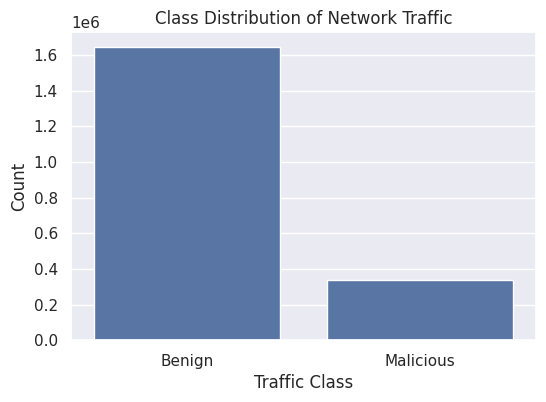

In [107]:
label_counts = data['Label'].value_counts()
print(label_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=data)
plt.title('Class Distribution of Network Traffic')
plt.xlabel('Traffic Class')
plt.ylabel('Count')
plt.show()

In [108]:
label_percent = data['Label'].value_counts(normalize=True) * 100
print(label_percent)

Label
Benign      83.07
Malicious   16.93
Name: proportion, dtype: float64


In [7]:
data[selected_features].hist(figsize=(20, 18), bins=30, edgecolor='black')
plt.suptitle('Histograms of Selected Behavioural Features', fontsize=16)
plt.tight_layout()
plt.show()

NameError: name 'selected_features' is not defined

In [113]:
print(data.columns.tolist())

['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 'Label']


In [114]:
data.columns = data.columns.str.strip()
print(data.columns.tolist())

['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 'Label']


In [115]:
missing = [col for col in selected_features if col not in data.columns]
print("Missing columns:", missing)

Missing columns: []


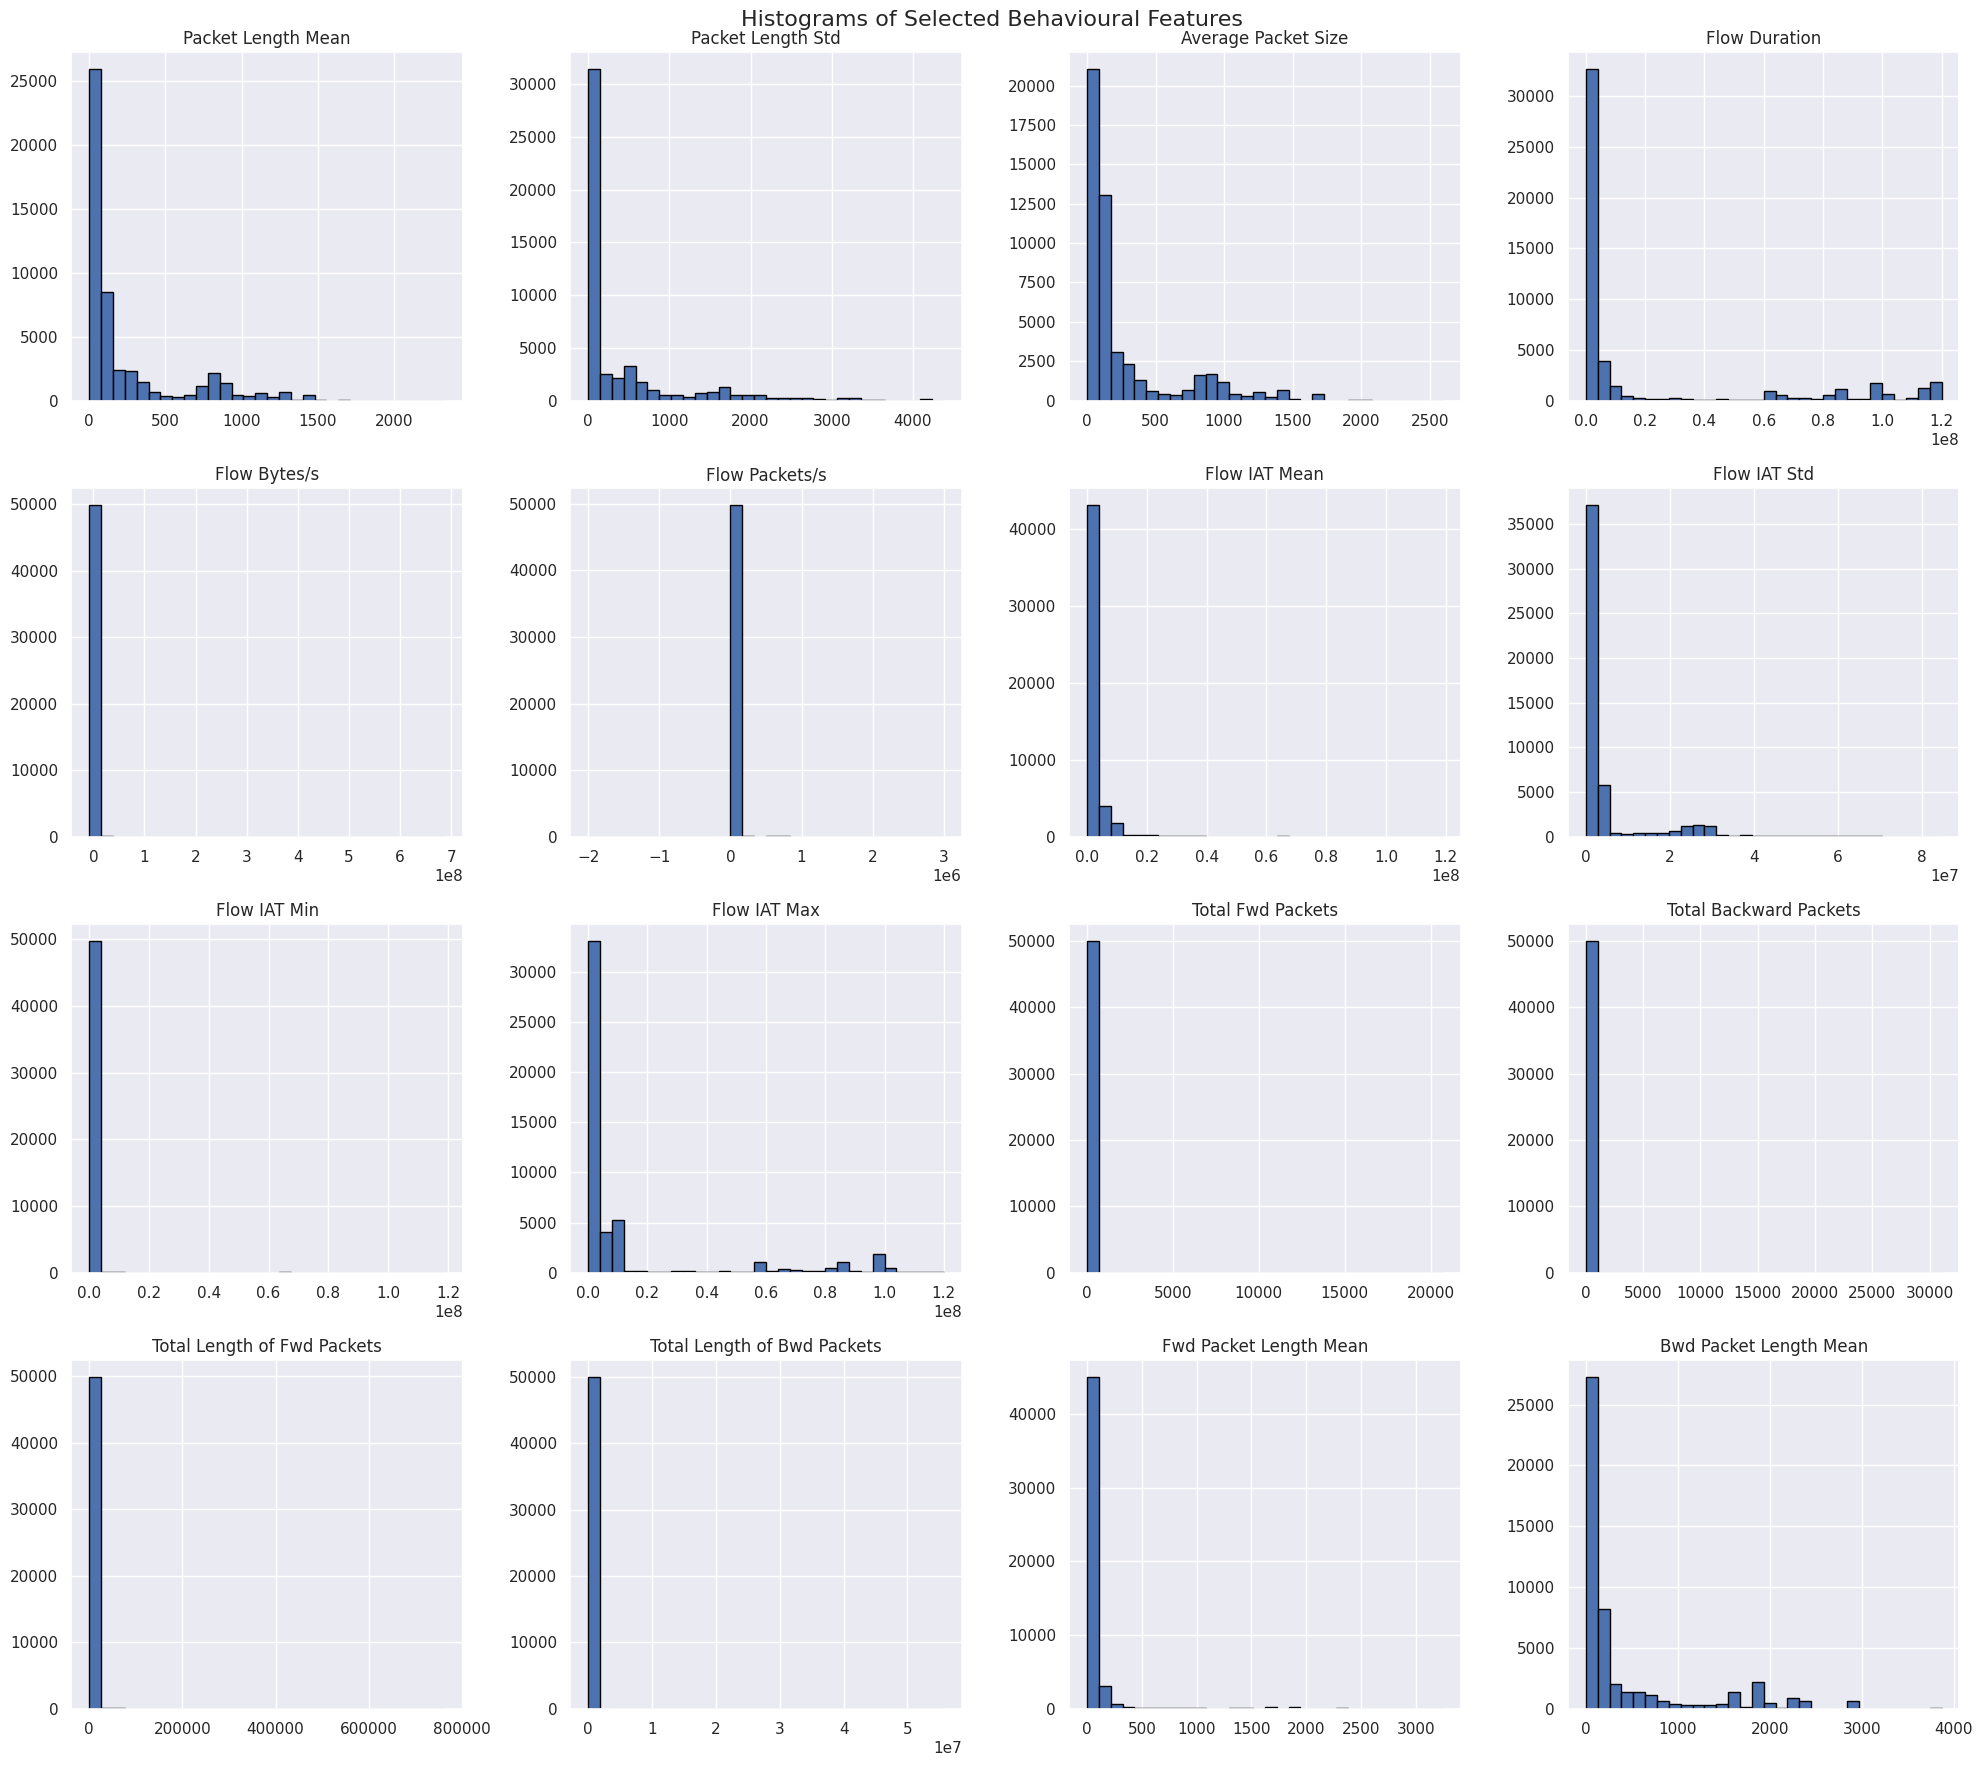

In [116]:
sample_data = data[selected_features].sample(n=50000, random_state=42)

sample_data.hist(figsize=(20, 18), bins=30, edgecolor='black')
plt.suptitle('Histograms of Selected Behavioural Features', fontsize=16)
plt.tight_layout()
plt.show()

In [117]:
import numpy as np

inf_counts = np.isinf(data[selected_features]).sum()
print(inf_counts)

Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Flow Duration                  0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Min                   0
Flow IAT Max                   0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Mean         0
Bwd Packet Length Mean         0
dtype: int64


In [118]:
data[selected_features] = data[selected_features].replace([np.inf, -np.inf], np.nan)

In [119]:
data[selected_features] = data[selected_features].fillna(0)

In [120]:
print(np.isinf(data[selected_features]).sum().sum())
print(data[selected_features].isnull().sum().sum())

0
0


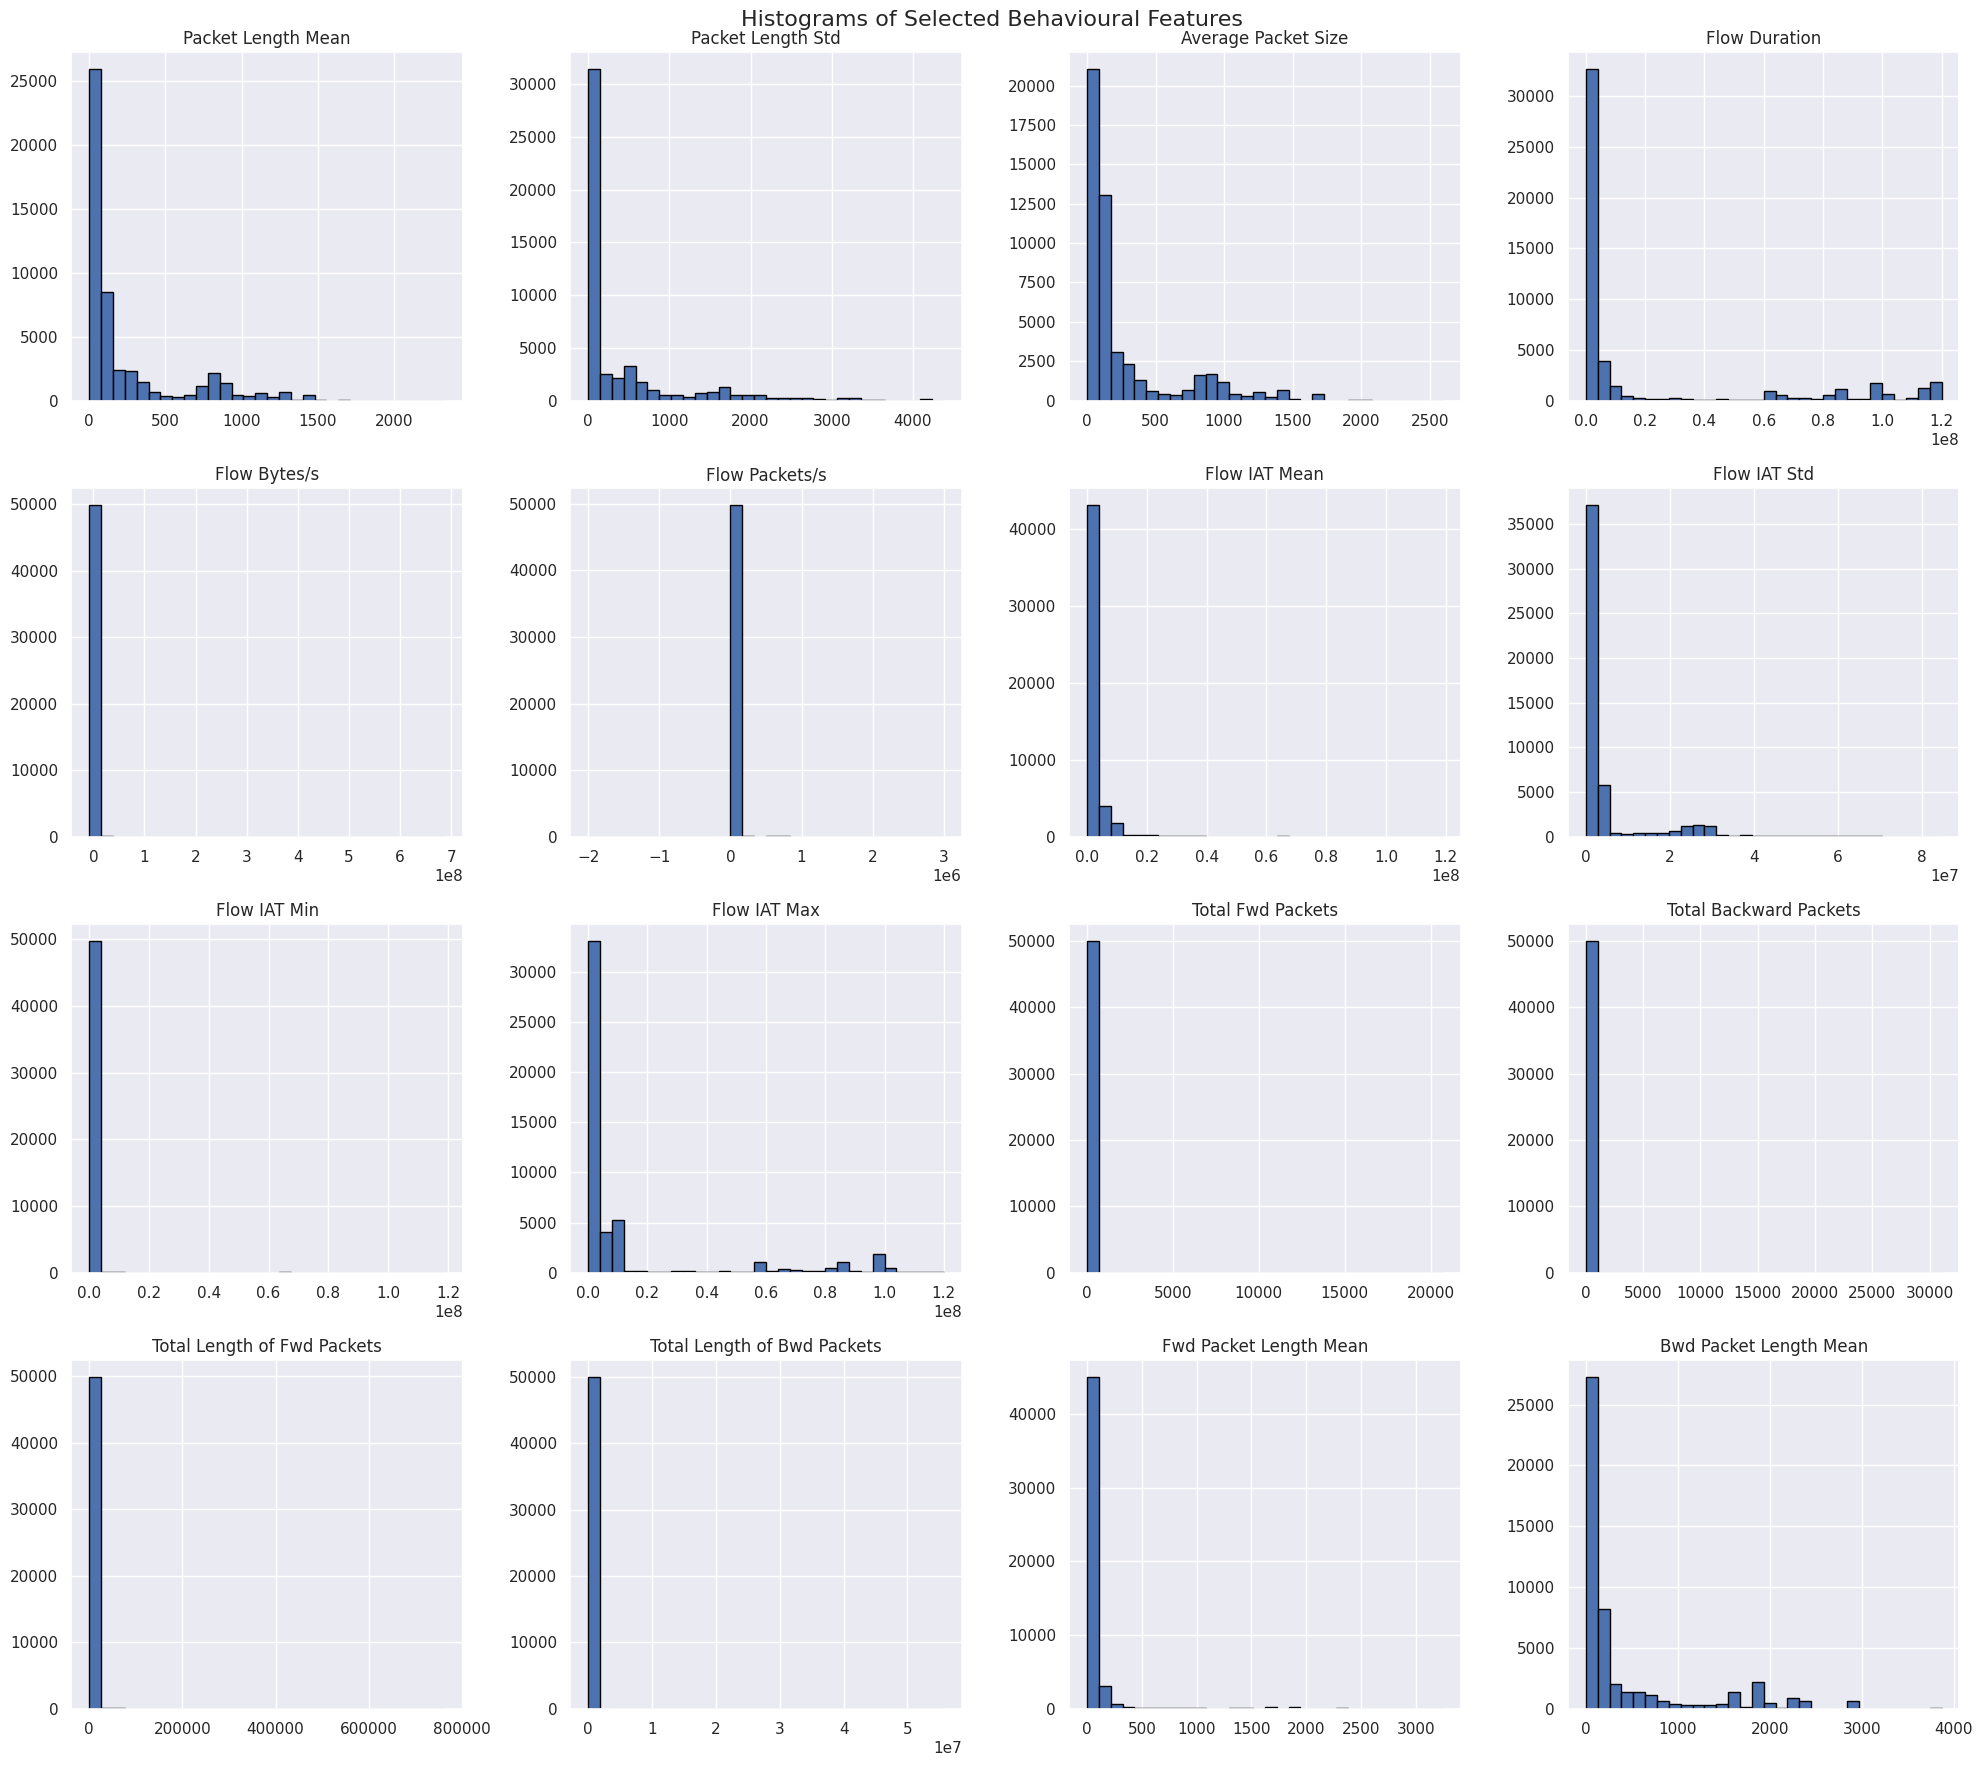

In [121]:
sample_data = data[selected_features].sample(n=50000, random_state=42)

sample_data.hist(figsize=(20, 18), bins=30, edgecolor='black')
plt.suptitle('Histograms of Selected Behavioural Features', fontsize=16)
plt.tight_layout()
plt.show()

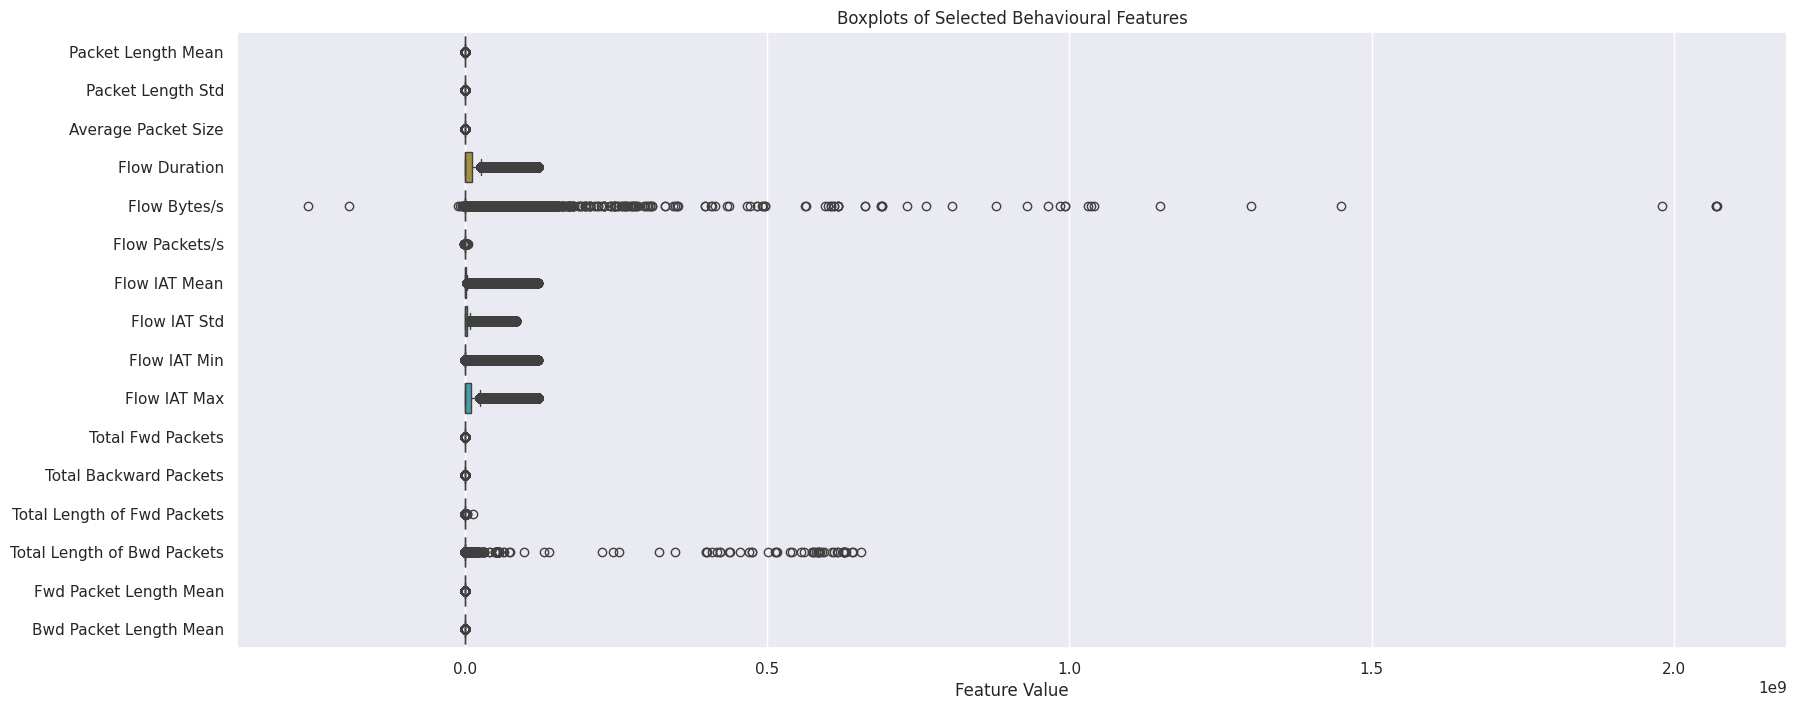

In [122]:
plt.figure(figsize=(20, 8))
sns.boxplot(data=data[selected_features], orient='h')
plt.title('Boxplots of Selected Behavioural Features')
plt.xlabel('Feature Value')
plt.show()

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


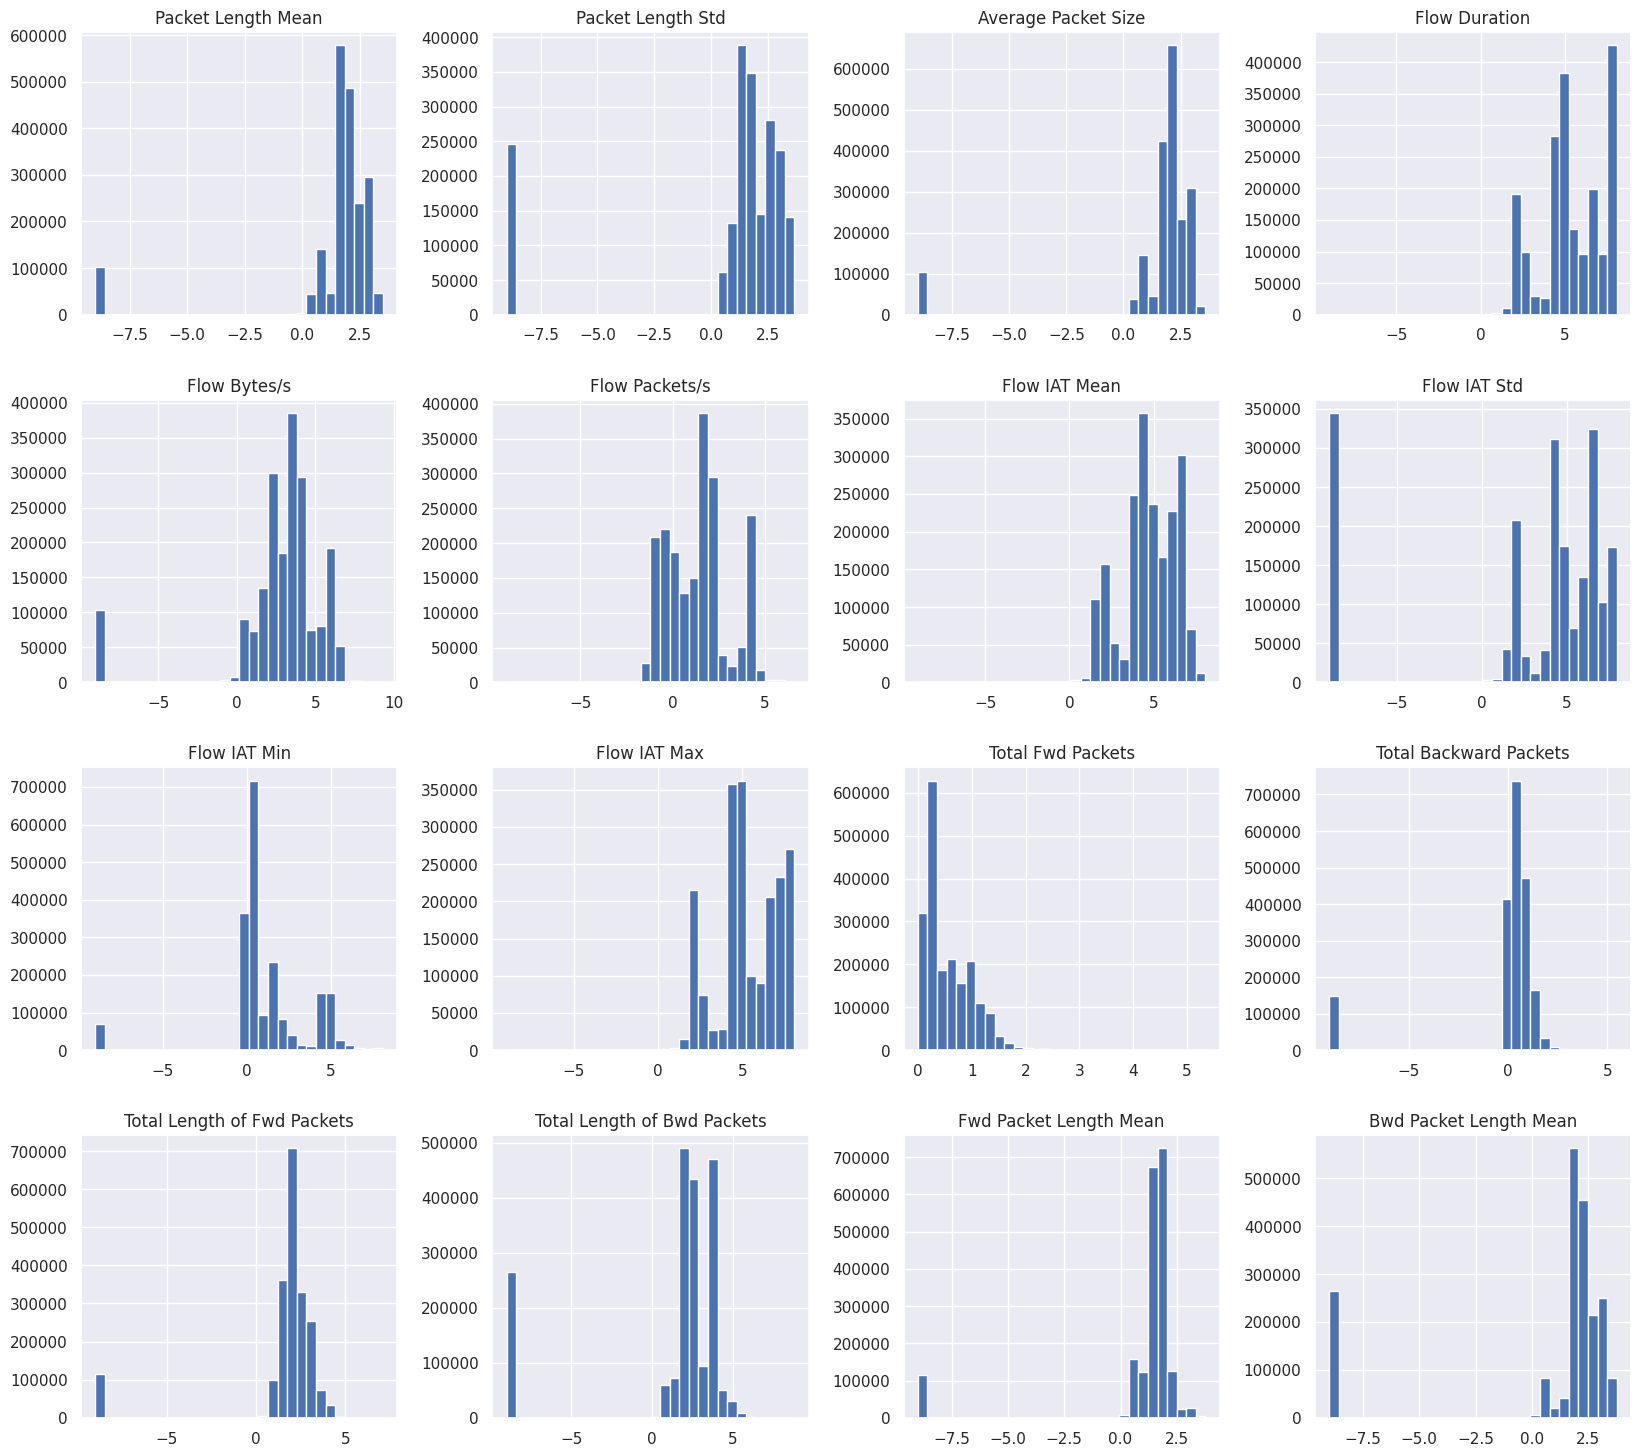

In [126]:
import numpy as np

log_data = data[selected_features].copy()
log_data = log_data.replace(0, 1e-9)
log_data = np.log10(log_data)

log_data.hist(figsize=(20, 18), bins=30)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


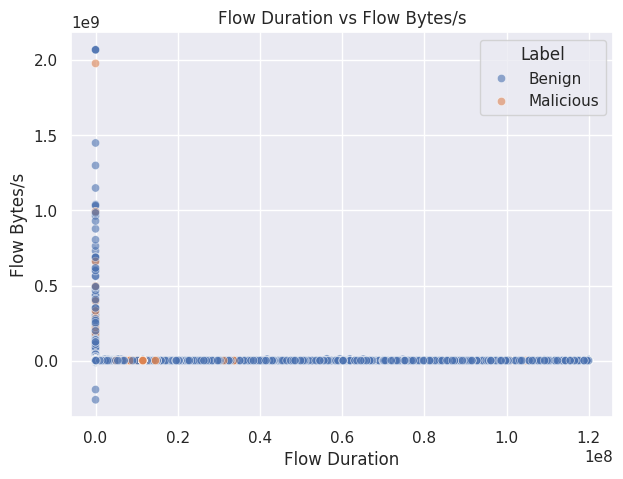

In [127]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=data,
    x='Flow Duration',
    y='Flow Bytes/s',
    hue='Label',
    alpha=0.6
)

plt.title('Flow Duration vs Flow Bytes/s')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


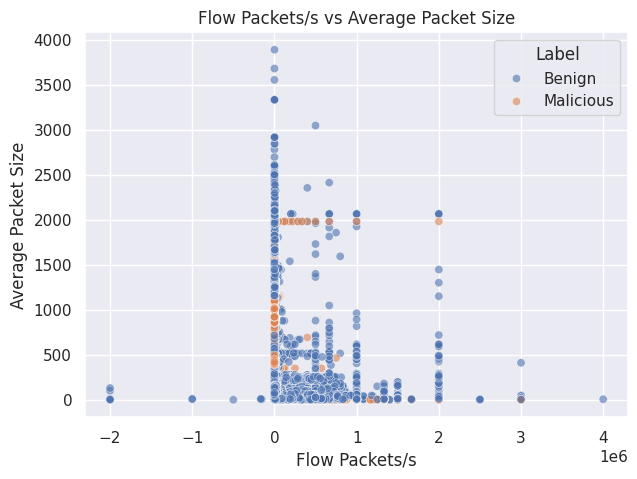

In [130]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=data,
    x='Flow Packets/s',
    y='Average Packet Size',
    hue='Label',
    alpha=0.6
)

plt.title('Flow Packets/s vs Average Packet Size')
plt.show()

In [131]:
sample_data = data[selected_features].sample(n=50000, random_state=42)

In [132]:
corr_matrix = sample_data.corr()
print(corr_matrix.head())

                     Packet Length Mean  Packet Length Std  \
Packet Length Mean                 1.00               0.94   
Packet Length Std                  0.94               1.00   
Average Packet Size                1.00               0.94   
Flow Duration                      0.37               0.40   
Flow Bytes/s                      -0.00              -0.02   

                     Average Packet Size  Flow Duration  Flow Bytes/s  \
Packet Length Mean                  1.00           0.37         -0.00   
Packet Length Std                   0.94           0.40         -0.02   
Average Packet Size                 1.00           0.35          0.00   
Flow Duration                       0.35           1.00         -0.04   
Flow Bytes/s                        0.00          -0.04          1.00   

                     Flow Packets/s  Flow IAT Mean  Flow IAT Std  \
Packet Length Mean            -0.05           0.13          0.37   
Packet Length Std             -0.05           0.17  

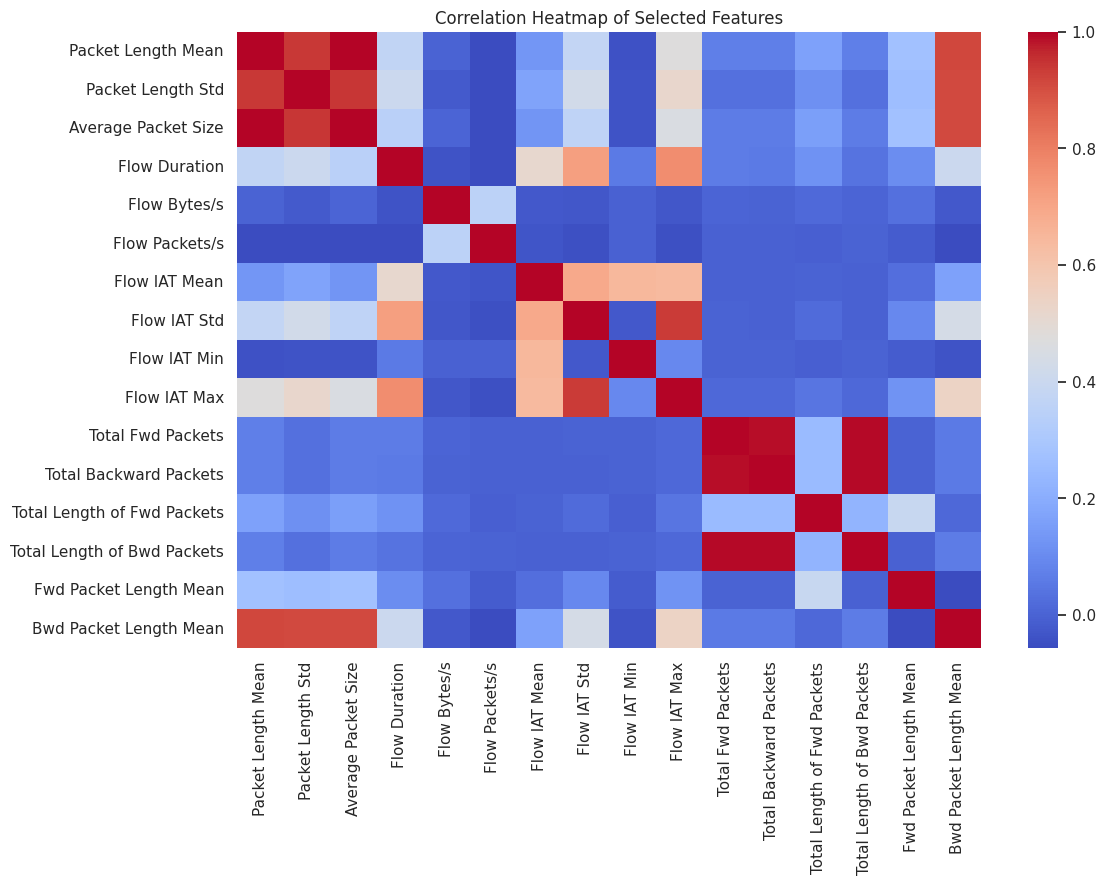

In [133]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False   # keep False for clean look
)

plt.title('Correlation Heatmap of Selected Features')
plt.show()

## Model Implementation

### Imported Libraries


In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, GridSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

### Converting the target data labels into binary labels

In [9]:
data['BinaryLabel'] = data['Label'].astype(str).str.strip().apply(lambda x:0 if x == 'Benign' else 1)

In [10]:
print(data['BinaryLabel'].value_counts())

BinaryLabel
0    125000
1    125000
Name: count, dtype: int64


In [11]:
X = data.drop(columns=['Label', 'BinaryLabel'])
y = data['BinaryLabel']

### Splitting the dataset for training and testing

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
print(y_train.value_counts())

BinaryLabel
0    100000
1    100000
Name: count, dtype: int64


### Model 1: Logistic Regression

In [41]:
m1_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

m1_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid=m1_params,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

m1_grid.fit(X_train_scaled, y_train)
print("Best Parameters for Model 1: ", m1_grid.best_params_)
print("Best CV Score of Model 1: ", m1_grid.best_score_)

m1_lr = m1_grid.best_estimator_
m1_pred = m1_lr.predict(X_test_scaled)
m1_prob = m1_lr.predict_proba(X_test_scaled)[:,1]

#temporary fix
import warnings
warnings.filterwarnings('ignore')

/Users/prachynar/Desktop/updated_proj/Encrypted_Network_Traffic_Behavioural_Analysis/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/prachynar/Desktop/updated_proj/Encrypted_Network_Traffic_Behavioural_Analysis/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/prachynar/Desktop/updated_proj/Encrypted_Network_Traffic_Behavioural_Analysis/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1

Best Parameters for Model 1:  {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score of Model 1:  0.9207


In [42]:
print("Results from M1: Logisitic Regression")
print("Accuracy:", accuracy_score(y_test, m1_pred))
print("Precision:", precision_score(y_test, m1_pred))
print("Recall:", recall_score(y_test, m1_pred))
print("F1-score:", f1_score(y_test, m1_pred))
print("ROC-AUC:", roc_auc_score(y_test, m1_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, m1_pred))
print(classification_report(y_test, m1_pred))

Results from M1: Logisitic Regression
Accuracy: 0.9167
Precision: 0.9609309322596346
Recall: 0.86872
F1-score: 0.9125018381966765
ROC-AUC: 0.9643043512
Confusion Matrix:
 [[24117   883]
 [ 3282 21718]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     25000
           1       0.96      0.87      0.91     25000

    accuracy                           0.92     50000
   macro avg       0.92      0.92      0.92     50000
weighted avg       0.92      0.92      0.92     50000



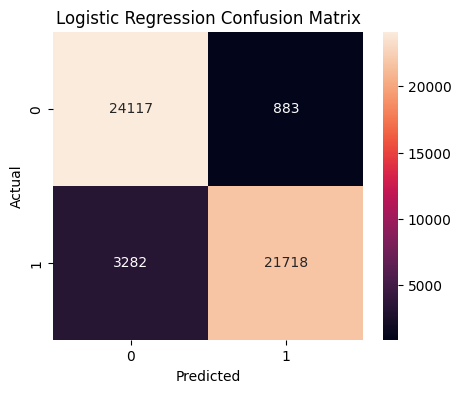

In [43]:
cm1 = confusion_matrix(y_test, m1_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm1, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
m1_fpr, m1_tpr, _ = roc_curve(y_test, m1_prob)

In [18]:
m1_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': m1_lr.coef_[0]
})

m1_coef['AbsCoefficient'] = np.abs(m1_coef['Coefficient'])
m1_coef = m1_coef.sort_values(by='AbsCoefficient', ascending=False)

print(m1_coef[['Feature', 'Coefficient']].head(10))

                        Feature  Coefficient
2        Total Backward Packets   -83.988261
1             Total Fwd Packets    35.923676
4   Total Length of Bwd Packets    13.374983
14            Packet Length Std    12.957960
6        Bwd Packet Length Mean   -11.345496
13           Packet Length Mean     9.713248
11                 Flow IAT Max     7.355171
15          Average Packet Size    -6.676837
5        Fwd Packet Length Mean    -6.041337
10                 Flow IAT Std    -4.878759


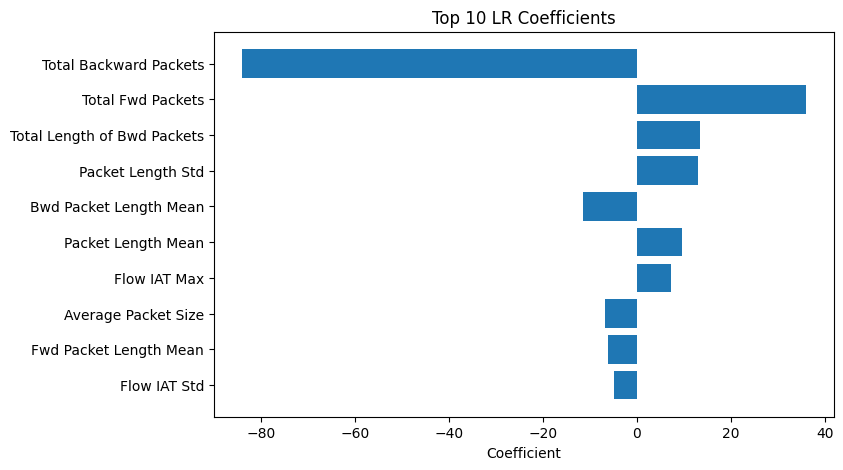

In [21]:
top_m1 = m1_coef.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_m1['Feature'], top_m1['Coefficient'])
plt.title("Top 10 LR Coefficients")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()
plt.show()

### Model 2: Random Forest

In [22]:
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    train_size=20000,
    random_state=42,
    stratify=y_train
)

In [23]:
m2_params = {
    'n_estimators': [100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
}

m2_grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=m2_params,
    cv=2,
    scoring='f1',
    n_jobs=-1
)

m2_grid.fit(X_train_sample, y_train_sample)
print("Best Parameters for Model 2: ", m2_grid.best_params_)
print("Best CV Score of Model 2: ", m2_grid.best_score_)

best_params = m2_grid.best_params_

m2_rf = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

m2_rf.fit(X_train, y_train)
m2_pred = m2_rf.predict(X_test)
m2_prob = m2_rf.predict_proba(X_test)[:, 1]

Best Parameters for Model 2:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score of Model 2:  0.9931044646459153


In [24]:
print("Results from M2: Random Forest")
print("Accuracy:", accuracy_score(y_test, m2_pred))
print("Precision:", precision_score(y_test, m2_pred))
print("Recall:", recall_score(y_test, m2_pred))
print("F1-score:", f1_score(y_test, m2_pred))
print("ROC-AUC:", roc_auc_score(y_test, m2_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, m2_pred))
print(classification_report(y_test, m2_pred))

Results from M2: Random Forest
Accuracy: 0.99514
Precision: 0.9947244314775588
Recall: 0.99556
F1-score: 0.9951420403430559
ROC-AUC: 0.9994060728
Confusion Matrix:
 [[24868   132]
 [  111 24889]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     25000
           1       0.99      1.00      1.00     25000

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



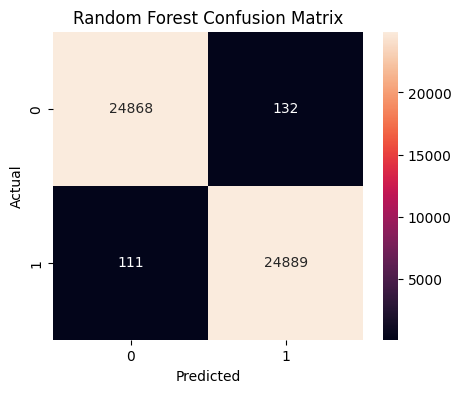

In [25]:
cm2 = confusion_matrix(y_test, m2_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
m2_fpr, m2_tpr, _ = roc_curve(y_test, m2_prob)

In [27]:
m2_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': m2_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(m2_importance.head(10))

                        Feature  Importance
6        Bwd Packet Length Mean    0.185695
15          Average Packet Size    0.155935
14            Packet Length Std    0.124768
13           Packet Length Mean    0.101347
4   Total Length of Bwd Packets    0.062596
1             Total Fwd Packets    0.061923
5        Fwd Packet Length Mean    0.058863
3   Total Length of Fwd Packets    0.058052
11                 Flow IAT Max    0.042254
2        Total Backward Packets    0.033369


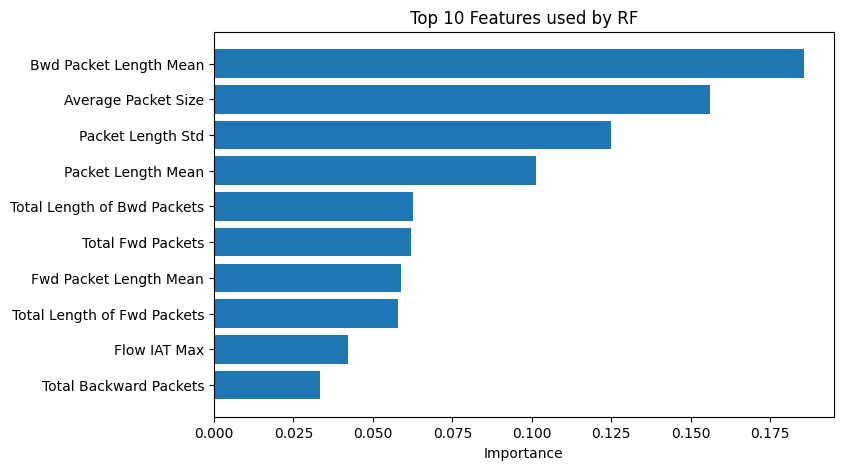

In [28]:
top_m2 = m2_importance.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_m2['Feature'], top_m2['Importance'])
plt.title("Top 10 Features used by RF")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

### Model 3: SVM

In [30]:
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=10000,
    random_state=42,
    stratify=y_train
)

In [31]:
m3_svm = SVC(
    C=1,
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

m3_svm.fit(X_train_svm, y_train_svm)

m3_pred = m3_svm.predict(X_test_scaled)
m3_prob = m3_svm.predict_proba(X_test_scaled)[:, 1]

In [32]:
print("Results from M3: Support Vector Machine")
print("Accuracy:", accuracy_score(y_test, m3_pred))
print("Precision:", precision_score(y_test, m3_pred))
print("Recall:", recall_score(y_test, m3_pred))
print("F1-score:", f1_score(y_test, m3_pred))
print("ROC-AUC:", roc_auc_score(y_test, m3_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, m3_pred))
print(classification_report(y_test, m3_pred))

Results from M3: Support Vector Machine
Accuracy: 0.85842
Precision: 0.9680334290937581
Recall: 0.74132
F1-score: 0.8396420885717522
ROC-AUC: 0.9546104264
Confusion Matrix:
 [[24388   612]
 [ 6467 18533]]
              precision    recall  f1-score   support

           0       0.79      0.98      0.87     25000
           1       0.97      0.74      0.84     25000

    accuracy                           0.86     50000
   macro avg       0.88      0.86      0.86     50000
weighted avg       0.88      0.86      0.86     50000



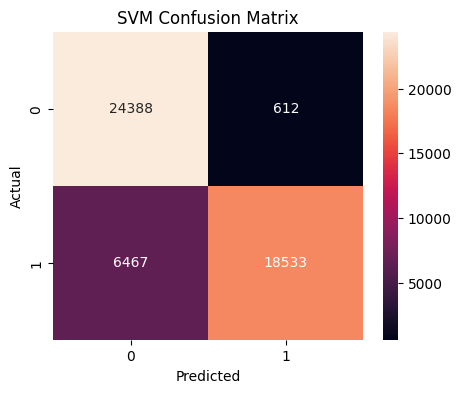

In [33]:
cm3 = confusion_matrix(y_test, m3_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm3, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
m3_fpr, m3_tpr, _ = roc_curve(y_test, m3_prob)

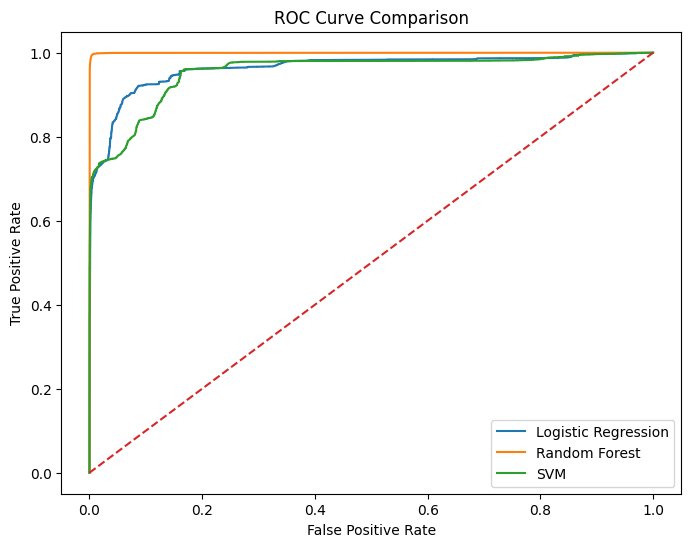

In [35]:
plt.figure(figsize=(8,6))
plt.plot(m1_fpr, m1_tpr, label='Logistic Regression')
plt.plot(m2_fpr, m2_tpr, label='Random Forest')
plt.plot(m3_fpr, m3_tpr, label='SVM')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

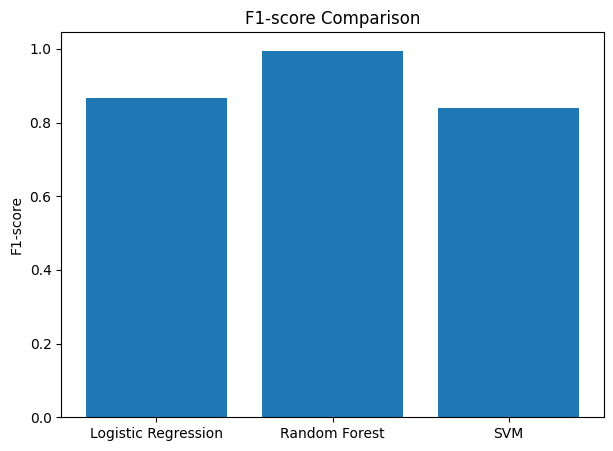

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'F1-score': [
        f1_score(y_test, m1_pred),
        f1_score(y_test, m2_pred),
        f1_score(y_test, m3_pred)
    ]
})
plt.figure(figsize=(7,5))
plt.bar(results['Model'], results['F1-score'])
plt.title("F1-score Comparison")
plt.ylabel("F1-score")
plt.show()